### Set Up

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, f1_score, precision_score, recall_score

import joblib  

### Loading .npz files

In [3]:
class EEGDataLoader:
  """Load .npz files containing EEG signals"""

  def __init__(self, data_dir=os.path.expanduser("~/Desktop/STATS_5243/Subjects_5243")):
        self.data_dir = data_dir

  def load_group(self, patient_list, w):
        """Loads data for a group of patients and returns optionally windowed features, depending on the input w"""
        X_group, y_group = [], []
        for pid in patient_list:
            fpath = os.path.join(self.data_dir, f"{pid}.npz")
            if not os.path.exists(fpath):
                print(f"Warning: {pid} not found. Skipping.")
                continue
            data = np.load(fpath)
            if w > 1:
                X_s, y_s = self._stack_features(data['X'], data['y'], w)
                X_group.append(X_s)
                y_group.append(y_s)
            else:
                X_group.append(data['X'])
                y_group.append(data['y'])

        if not X_group: raise ValueError("No data found!")
        return np.concatenate(X_group, axis=0), np.concatenate(y_group, axis=0)

  def _stack_features(self, X, y, w):
        """Groups several nearby epochs together into one feature block."""
        n_epochs = X.shape[0]
        if n_epochs < w: return np.empty((0, X.shape[1]*w)), np.empty((0,))
        X_new = [X[i : n_epochs - w + 1 + i] for i in range(w)]
        X_new.reverse()
        return np.concatenate(X_new, axis=1), y[w-1:]

### Handling Class Imbalance

In [4]:
def undersample_majority(X, y, target_minority_ratio=0.10):
  """Undersamples the majority class"""
  idx_min = np.where(y == 1)[0]
  idx_maj = np.where(y == 0)[0]
  n_min = len(idx_min)
  
  n_maj_new = int((n_min / target_minority_ratio) - n_min)

  if n_maj_new >= len(idx_maj): return X, y

  np.random.seed(42)
  idx_maj_down = np.random.choice(idx_maj, size=n_maj_new, replace=False)
  idx_combo = np.concatenate([idx_min, idx_maj_down])
  np.random.shuffle(idx_combo)

  return X[idx_combo], y[idx_combo]

### Logistic Regression

In [5]:
def run_logistic_grid_patient_split(X_train, y_train, X_val, y_val, undersample_configs, C_values):
    """Runs logistic regression (grid search)"""
    
    results = []
    models = []   
    scalers = [] 

    for ratio in undersample_configs:

        # Undersample
        X_train_u, y_train_u = undersample_majority(
            X_train, y_train, target_minority_ratio=ratio
        )
        print(f"\nUndersample ratio={ratio}: {sum(y_train_u==1)} pos / {sum(y_train_u==0)} neg")

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_u)
        X_val_scaled   = scaler.transform(X_val)

        for C in C_values:

            model = LogisticRegression(C=C, solver="liblinear", max_iter=1000, random_state=42)

            # Train
            t0 = time.time()
            model.fit(X_train_scaled, y_train_u)
            train_time = time.time() - t0

            # Predict
            y_pred = model.predict(X_val_scaled)
            y_prob = model.predict_proba(X_val_scaled)[:, 1]

            # Metrics (positive class = seizures)
            precision = precision_score(y_val, y_pred, pos_label=1)
            recall    = recall_score(y_val, y_pred, pos_label=1)
            f1        = f1_score(y_val, y_pred, pos_label=1)
            auc       = roc_auc_score(y_val, y_prob)
            acc       = accuracy_score(y_val, y_pred)

            results.append({
                "undersample_ratio": ratio,
                "C": C,
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
                "AUC": auc,
                "Accuracy": acc,
                "Train Samples": len(y_train_u),
                "Train Time (s)": train_time
            })

            models.append(model)  
            scalers.append(scaler) 

    df = pd.DataFrame(results)
    return df, models, scalers 


In [6]:
if __name__ == "__main__":
    loader = EEGDataLoader()
    window_size = 3

    # Independent split
    train_pats = [
        'chb16', 'chb10', 'chb01', 'chb09', 'chb19', 'chb13',
        'chb02', 'chb14', 'chb06', 'chb03', 'chb12', 'chb22',
        'chb04', 'chb05', 'chb17a', 'chb17b', 'chb17c'
    ]
    val_pats  = ['chb20', 'chb18', 'chb23', 'chb24']
    test_pats = ['chb08', 'chb11', 'chb15', 'chb21', 'chb07']

    print("Loading data…")
    X_train, y_train = loader.load_group(train_pats, window_size)
    X_val, y_val     = loader.load_group(val_pats, window_size)
    X_test, y_test   = loader.load_group(test_pats, window_size)

    # Hyperparameters to evaluate
    undersample_configs = [0.02, 0.05, 0.10, 0.5]
    C_values = [0.001, 0.01]

    # Run grid search
    results_df, models, scalers = run_logistic_grid_patient_split(
        X_train, y_train,
        X_val, y_val,
        undersample_configs,
        C_values
    )

    print("\nValidation results (sorted by F1):")
    print(results_df.sort_values("F1", ascending=False).to_string(index=False))

    # Select top 3 validation configs
    top3 = results_df.sort_values("F1", ascending=False).head(3)
    print("\nTop 3 configs (validation F1):")
    print(top3[["undersample_ratio", "C", "F1"]].to_string(index=False))

    # Retrain top 3 configs on Train+Val and evaluate on Test
    final_results = []
    final_models = []
    final_scalers = []

    print("\nEvaluating top 3 configs on TEST…")

    for i, row in top3.iterrows():
        ratio = float(row["undersample_ratio"])
        C_val = float(row["C"])

        # Train+Val combined
        X_full = np.vstack([X_train, X_val])
        y_full = np.concatenate([y_train, y_val])

        # Undersample
        X_u, y_u = undersample_majority(X_full, y_full, ratio)

        # Scale
        scaler_f = StandardScaler()
        X_u_scaled = scaler_f.fit_transform(X_u)
        X_test_scaled = scaler_f.transform(X_test)

        # Fit model
        model_f = LogisticRegression(C=C_val, solver="liblinear", max_iter=1000)
        model_f.fit(X_u_scaled, y_u)

        # Predictions
        y_pred = model_f.predict(X_test_scaled)
        y_prob = model_f.predict_proba(X_test_scaled)[:, 1]

        # Metrics
        res = {
            "undersample_ratio": ratio,
            "C": C_val,
            "Test_Accuracy": accuracy_score(y_test, y_pred),
            "Test_Precision": precision_score(y_test, y_pred, zero_division=0),
            "Test_Recall": recall_score(y_test, y_pred, zero_division=0),
            "Test_F1": f1_score(y_test, y_pred, zero_division=0),
            "Test_AUC": roc_auc_score(y_test, y_prob)
        }

        final_results.append(res)
        final_models.append(model_f)
        final_scalers.append(scaler_f)

    # Printing results
    final_df = pd.DataFrame(final_results)
    print("\nTop-3 model performance on TEST:")
    print(final_df.sort_values("Test_F1", ascending=False).to_string(index=False))

    # Best test model
    best_idx = final_df["Test_F1"].idxmax()
    best_row = final_df.loc[best_idx]

    print("\nBest model on TEST:")
    print(best_row)

    # Save best model
    joblib.dump(final_models[best_idx], "best_logreg_model.pkl")
    joblib.dump(final_scalers[best_idx], "best_logreg_scaler.pkl")
    print("\nSaved best model and scaler.")

Loading data…

Undersample ratio=0.02: 2726 pos / 133574 neg

Undersample ratio=0.05: 2726 pos / 51794 neg

Undersample ratio=0.1: 2726 pos / 24534 neg

Undersample ratio=0.5: 2726 pos / 2726 neg

Validation results (sorted by F1):
 undersample_ratio     C  Precision   Recall       F1      AUC  Accuracy  Train Samples  Train Time (s)
              0.50 0.001   0.102420 0.368222 0.160263 0.886413  0.983299           5452        0.148174
              0.50 0.010   0.086864 0.465322 0.146400 0.884226  0.976515           5452        0.378677
              0.02 0.001   0.111893 0.200504 0.143631 0.828631  0.989652         136300       11.490552
              0.05 0.001   0.103819 0.219420 0.140948 0.848986  0.988424          54520        4.533525
              0.02 0.010   0.101305 0.205549 0.135720 0.801335  0.988669         136300       30.364406
              0.10 0.001   0.096063 0.230769 0.135656 0.855681  0.987272          27260        1.956521
              0.05 0.010   0.095264 0.22

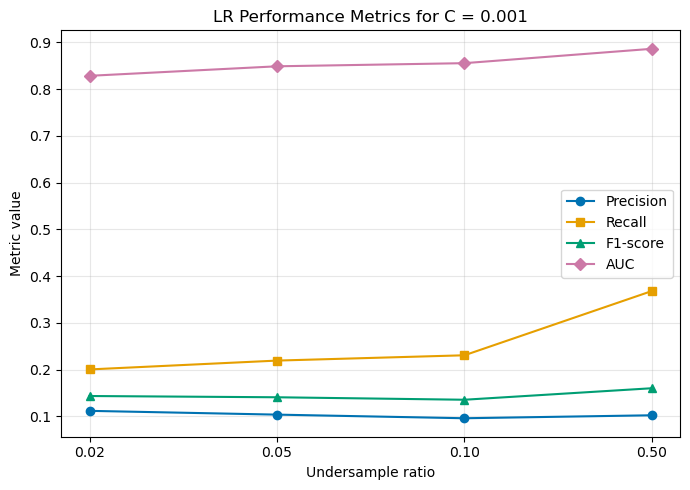

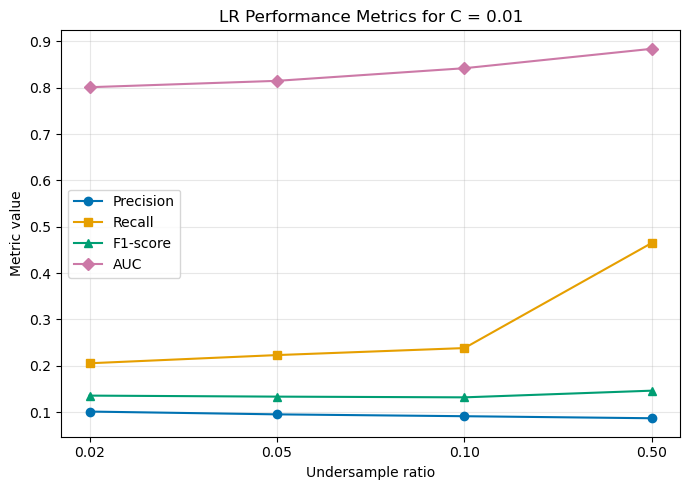

In [7]:
# Plotting
unique_Cs = sorted(results_df["C"].unique())

# Colorblind-friendly colors (Okabe–Ito)
colors = {
    "Precision": "#0072B2",
    "Recall":    "#E69F00",
    "F1":        "#009E73",
    "AUC":       "#CC79A7",
}

for C_val in unique_Cs:

    df_c = results_df[results_df["C"] == C_val].copy()
    df_c = df_c.sort_values("undersample_ratio")

    ratios = df_c["undersample_ratio"].values
    x_idx = np.arange(len(ratios))

    plt.figure(figsize=(7, 5))

    # Plot metrics
    plt.plot(x_idx, df_c["Precision"], marker="o", color=colors["Precision"], label="Precision")
    plt.plot(x_idx, df_c["Recall"],    marker="s", color=colors["Recall"],    label="Recall")
    plt.plot(x_idx, df_c["F1"],        marker="^", color=colors["F1"],        label="F1-score")
    plt.plot(x_idx, df_c["AUC"],       marker="D", color=colors["AUC"],       label="AUC")

    # Axis formatting
    plt.xticks(x_idx, [f"{r:.2f}" for r in ratios])
    plt.xlabel("Undersample ratio")
    plt.ylabel("Metric value")
    plt.title(f"LR Performance Metrics for C = {C_val}")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()